# 🏠 Real Estate ML Model Analysis

Comprehensive ML model comparison for Varaždin real estate price prediction.

**Features:**
- Data cleaning and outlier removal
- Feature engineering matching the production app
- All 12 ML models from the app (Linear, Tree-based, Neural Network, etc.)
- Cross-validation and performance metrics
- Feature importance analysis
- Model comparison visualizations


In [32]:
# Install required packages to the KERNEL's Python
import sys
print(f"Kernel Python: {sys.executable}")

# Install all required packages including xgboost for full model support
!{sys.executable} -m pip install scikit-learn pandas numpy matplotlib seaborn plotly supabase python-dotenv scipy xgboost -q
print("✅ Packages installed to kernel's Python")


Kernel Python: /opt/homebrew/opt/python@3.11/bin/python3.11

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
✅ Packages installed to kernel's Python


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ML imports - matching the app's ml_service.py
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, BayesianRidge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Try to import XGBoost (optional but preferred)
try:
    import xgboost as xgb
    HAS_XGBOOST = True
    print("✅ XGBoost available")
except ImportError:
    HAS_XGBOOST = False
    print("⚠️ XGBoost not available, using GradientBoosting fallback")

# Set style
plt.style.use('dark_background')
sns.set_palette('viridis')

print("✅ All libraries loaded successfully!")


✅ XGBoost available
✅ All libraries loaded successfully!


## 1. Load Data from Supabase


In [46]:
import os
from dotenv import load_dotenv
from supabase import create_client

# Load environment variables
load_dotenv('/Users/lukamindek/Desktop/real-estater/backend/.env')

# Connect to Supabase
supabase_url = os.getenv('SUPABASE_URL')
supabase_key = os.getenv('SUPABASE_KEY') or os.getenv('SUPABASE_ANON_KEY')

client = create_client(supabase_url, supabase_key)

# Fetch all listings from listings_v3 (matching the app's ML router)
result = client.table('listings_v2').select('*').execute()
df_raw = pd.DataFrame(result.data)

print(f"✅ Loaded {len(df_raw)} raw listings from listings_v3")
df_raw.head(3)


✅ Loaded 479 raw listings from listings_v3


,id,external_id,url,title,price_eur,location_city,location_district,floor_level,latitude,longitude,...,images,additional_info,seller_name,seller_contact,scrape_job_id,raw_data,created_at,updated_at,interior_arranged,has_cellar
0,62f795ed-8a74-400e-8578-87d8de68fb22,39347142,https://www.njuskalo.hr/nekretnine/varazdin-4-...,"Varaždin; 4-sobni penthouse od 162.10 m2, NOVO...",502510.0,Varaždin,Varaždin,5.,46.309327,16.337605,...,"[{'id': '256235982', 'src': 'https://www.njusk...","{'Dozvole': ['Vlasnički list', 'Građevinska do...",EUROESTATE - ovlašteni posrednik u prometu nek...,https://euroestate-nekretnine.hr/,c4811ab3-e8bc-446d-9f16-043c9b4c00ef,"{'ad_id': '39347142', 'price': '502.510 €', 't...",2025-12-01T19:52:40.717427+00:00,2025-12-01T19:52:40.717427+00:00,False,True
1,cf87561e-7fcd-4718-b770-e69b8e6eed2a,39346734,https://www.njuskalo.hr/nekretnine/varazdin-4-...,"Varaždin: 4-sobni penthouse,160.53 m2, A +, NO...",497643.0,Varaždin,Varaždin,5.,46.308307,16.343466,...,"[{'id': '256330045', 'src': 'https://www.njusk...","{'Dozvole': ['Vlasnički list', 'Građevinska do...",EUROESTATE - ovlašteni posrednik u prometu nek...,https://euroestate-nekretnine.hr/,c4811ab3-e8bc-446d-9f16-043c9b4c00ef,"{'ad_id': '39346734', 'price': '497.643 €', 't...",2025-12-01T19:52:44.636304+00:00,2025-12-01T19:52:44.636304+00:00,False,True
2,2a9991a3-e151-4819-8ab5-ae75e08f773e,48620881,https://www.njuskalo.hr/nekretnine/novogradnja...,NOVOGRADNJA U SRCU NOVOG MAROFA – MODERAN STAN...,NaN,Varaždin,Novi Marof,None,46.162530,16.335030,...,"[{'id': '262039869', 'src': 'https://www.njusk...","{'Dozvole': ['Građevinska dozvola'], 'Grijanje...",CENTURY 21 V i A NEKRETNINE,https://c21.hr/c21-agencije/p/century-21-via-n...,c4811ab3-e8bc-446d-9f16-043c9b4c00ef,"{'ad_id': '48620881', 'price': '167.346 €', 't...",2025-12-01T19:53:06.806478+00:00,2025-12-01T19:53:06.806478+00:00,None,None


In [47]:
# ============================================
# DATA CLEANING - Matching the app's approach
# ============================================
# The app filters: price_eur >= 10000 AND living_area_m2 >= 10

df = df_raw.copy()

# Convert numeric columns (matching MLService._prepare_dataframe)
numeric_cols = ['price_eur', 'living_area_m2', 'outdoor_area_m2', 'bedroom_count', 
                'bathroom_count', 'renovation_level', 'distance_from_center', 'year_built']

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Apply the same filters as the app's get_filtered_listings()
df_clean = df[
    (df['price_eur'].notna()) & 
    (df['price_eur'] >= 10000) &  # Min €10k (app's filter)
    (df['living_area_m2'].notna()) &
    (df['living_area_m2'] >= 10)   # Min 10m² (app's filter)
].copy()

print(f"📊 Data Cleaning Results:")
print(f"   Raw listings:     {len(df_raw)}")
print(f"   After cleaning:   {len(df_clean)} ({len(df_clean)/len(df_raw)*100:.1f}%)")
print(f"   Removed:          {len(df_raw) - len(df_clean)} outliers/invalid")

# Calculate derived metrics
df_clean['price_per_m2'] = df_clean['price_eur'] / df_clean['living_area_m2']

# Quick stats
df_clean[['price_eur', 'living_area_m2', 'price_per_m2', 'renovation_level']].describe()


📊 Data Cleaning Results:
   Raw listings:     479
   After cleaning:   116 (24.2%)
   Removed:          363 outliers/invalid


,price_eur,living_area_m2,price_per_m2,renovation_level
count,116.000000,116.000000,116.000000,116.000000
mean,303484.311293,124.647328,2522.459366,6.965517
std,196765.670152,100.131161,859.616168,2.004044
min,46000.000000,27.000000,386.273075,3.000000
25%,138750.000000,66.500000,1995.867769,5.000000
50%,245000.000000,104.000000,2456.896552,7.000000
75%,450000.000000,160.897500,3061.405863,9.000000
max,854404.000000,983.760000,4979.474453,9.000000


## 2. Feature Engineering (Matching Production App)

Create derived features and prepare data exactly as the app's `MLService` does.


In [48]:
# ============================================
# FEATURE ENGINEERING - Exactly matching MLService
# ============================================

# Feature definitions from the app's ml_service.py
NUMERIC_FEATURES = [
    'living_area_m2',       # Size - strongest predictor
    'bedroom_count',        # Room count
    'bathroom_count',       # Bathroom count
    'outdoor_area_m2',      # Outdoor space premium
    'renovation_level',     # 1-10 condition score
    'distance_from_center', # Distance from city center in km
]

DERIVED_FEATURES = [
    'has_garage',           # parking_type == 'GARAGE'
    'is_house',             # building_type == 'HOUSE'
    'is_furnished',         # interior_arranged == True
    'has_cellar',           # has_cellar == True
]

CATEGORICAL_FEATURES = ['location_district']
BOOLEAN_FEATURES = ['is_new_construction']
TARGET = 'price_eur'

# Create derived binary features (matching MLService._prepare_dataframe)
df_ml = df_clean.copy()

# Convert boolean to float
if 'is_new_construction' in df_ml.columns:
    df_ml['is_new_construction'] = df_ml['is_new_construction'].fillna(False).astype(float)

# has_garage: parking_type == 'GARAGE'
if 'parking_type' in df_ml.columns:
    df_ml['has_garage'] = (df_ml['parking_type'] == 'GARAGE').astype(float)
else:
    df_ml['has_garage'] = 0.0

# is_house: building_type == 'HOUSE'
if 'building_type' in df_ml.columns:
    df_ml['is_house'] = (df_ml['building_type'] == 'HOUSE').astype(float)
else:
    df_ml['is_house'] = 0.0

# is_furnished: interior_arranged == True
if 'interior_arranged' in df_ml.columns:
    df_ml['is_furnished'] = df_ml['interior_arranged'].fillna(False).astype(float)
else:
    df_ml['is_furnished'] = 0.0

# has_cellar: directly from database
if 'has_cellar' in df_ml.columns:
    df_ml['has_cellar'] = df_ml['has_cellar'].fillna(False).astype(float)
else:
    df_ml['has_cellar'] = 0.0

# Fill NaN in numeric features with median
for col in NUMERIC_FEATURES:
    if col in df_ml.columns:
        df_ml[col] = df_ml[col].fillna(df_ml[col].median())

# Fill NaN in categorical with 'Unknown'
for col in CATEGORICAL_FEATURES:
    if col in df_ml.columns:
        df_ml[col] = df_ml[col].fillna('Unknown').astype(str)

print("=" * 60)
print("FEATURE ENGINEERING COMPLETE")
print("=" * 60)
print(f"\n📊 Dataset ready for ML:")
print(f"   Total samples: {len(df_ml)}")
print(f"\n   Numeric features ({len(NUMERIC_FEATURES)}):")
for f in NUMERIC_FEATURES:
    if f in df_ml.columns:
        print(f"      • {f}: {df_ml[f].notna().sum()} non-null, median={df_ml[f].median():.1f}")

print(f"\n   Derived binary features ({len(DERIVED_FEATURES)}):")
for f in DERIVED_FEATURES:
    if f in df_ml.columns:
        pct = df_ml[f].mean() * 100
        print(f"      • {f}: {pct:.1f}% True")

print(f"\n   Categorical features: {CATEGORICAL_FEATURES}")
print(f"   Boolean features: {BOOLEAN_FEATURES}")
print(f"\n   Target: {TARGET} (median: €{df_ml[TARGET].median():,.0f})")


FEATURE ENGINEERING COMPLETE

📊 Dataset ready for ML:
   Total samples: 116

   Numeric features (6):
      • living_area_m2: 116 non-null, median=104.0
      • bedroom_count: 116 non-null, median=2.0
      • bathroom_count: 116 non-null, median=1.0
      • outdoor_area_m2: 116 non-null, median=44.7
      • renovation_level: 116 non-null, median=7.0
      • distance_from_center: 116 non-null, median=0.4

   Derived binary features (4):
      • has_garage: 34.5% True
      • is_house: 13.8% True
      • is_furnished: 50.0% True
      • has_cellar: 67.2% True

   Categorical features: ['location_district']
   Boolean features: ['is_new_construction']

   Target: price_eur (median: €245,000)


## 3. Box Plots Visualization


In [49]:
# ============================================
# PREPROCESSING PIPELINE - Matching MLService._prepare_features
# ============================================

# Get available columns
available_numeric = [c for c in NUMERIC_FEATURES if c in df_ml.columns]
available_derived = [c for c in DERIVED_FEATURES if c in df_ml.columns]
available_categorical = [c for c in CATEGORICAL_FEATURES if c in df_ml.columns]
available_boolean = [c for c in BOOLEAN_FEATURES if c in df_ml.columns]

# Combine all features
all_features = available_numeric + available_derived + available_categorical + available_boolean
X_df = df_ml[all_features].copy()
y = df_ml[TARGET].values

# Create preprocessor (matching the app exactly)
transformers = []

# Numeric features: StandardScaler
if available_numeric:
    transformers.append(('num', StandardScaler(), available_numeric))

# Derived binary features: passthrough (already 0/1)
if available_derived:
    transformers.append(('derived', 'passthrough', available_derived))

# Categorical features: OneHotEncoder
if available_categorical:
    transformers.append(('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), available_categorical))

# Boolean features: passthrough (already 0/1)
if available_boolean:
    transformers.append(('bool', 'passthrough', available_boolean))

preprocessor = ColumnTransformer(transformers, remainder='drop')
X = preprocessor.fit_transform(X_df)

# Get feature names for interpretability
feature_names_out = available_numeric + available_derived
if available_categorical and hasattr(preprocessor.named_transformers_.get('cat', None), 'get_feature_names_out'):
    cat_features = preprocessor.named_transformers_['cat'].get_feature_names_out(available_categorical)
    feature_names_out.extend(cat_features)
feature_names_out.extend(available_boolean)

# Split data (matching app's default test_size=0.2)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("=" * 60)
print("PREPROCESSING COMPLETE")
print("=" * 60)
print(f"\n📊 Data shapes:")
print(f"   X_train: {X_train.shape}")
print(f"   X_test:  {X_test.shape}")
print(f"   Features: {len(feature_names_out)}")
print(f"\n   Feature names: {feature_names_out}")


PREPROCESSING COMPLETE

📊 Data shapes:
   X_train: (92, 22)
   X_test:  (24, 22)
   Features: 22

   Feature names: ['living_area_m2', 'bedroom_count', 'bathroom_count', 'outdoor_area_m2', 'renovation_level', 'distance_from_center', 'has_garage', 'is_house', 'is_furnished', 'has_cellar', 'location_district_Hrašćica', 'location_district_Ivanec', 'location_district_Jalkovec', 'location_district_Klenovnik', 'location_district_Ludbreg', 'location_district_Maruševec', 'location_district_Novi Marof', 'location_district_Petrijanec', 'location_district_Varaždin', 'location_district_Varaždinske Toplice', 'location_district_Visoko', 'is_new_construction']


## 4. Define All ML Models (Same as Production App)


In [50]:
# ============================================
# MODEL DEFINITIONS - Matching MLService.get_model()
# ============================================
# All 12 models from the app with their default parameters

MODELS = {
    # === LINEAR MODELS ===
    'linear_regression': {
        'name': 'Linear Regression',
        'category': 'linear',
        'model': LinearRegression(),
        'description': 'Simple baseline. Shows raw feature coefficients.',
    },
    'ridge': {
        'name': 'Ridge Regression',
        'category': 'linear',
        'model': Ridge(alpha=1.0, random_state=42),
        'description': 'L2 regularization prevents overfitting. Best for small datasets.',
    },
    'lasso': {
        'name': 'Lasso Regression',
        'category': 'linear',
        'model': Lasso(alpha=1.0, random_state=42, max_iter=10000),
        'description': 'L1 regularization. Automatically selects important features.',
    },
    'elastic_net': {
        'name': 'Elastic Net',
        'category': 'linear',
        'model': ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=42, max_iter=10000),
        'description': 'Combines Ridge + Lasso. Good balance.',
    },
    'bayesian_ridge': {
        'name': 'Bayesian Ridge',
        'category': 'linear',
        'model': BayesianRidge(),
        'description': 'Probabilistic. Provides uncertainty estimates.',
    },
    
    # === TREE-BASED MODELS ===
    'decision_tree': {
        'name': 'Decision Tree',
        'category': 'tree',
        'model': DecisionTreeRegressor(max_depth=10, random_state=42),
        'description': 'Simple tree. Shows feature importance but can overfit.',
    },
    'random_forest': {
        'name': 'Random Forest',
        'category': 'tree',
        'model': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
        'description': 'Ensemble of trees. Robust and handles non-linearity.',
    },
    'gradient_boosting': {
        'name': 'Gradient Boosting',
        'category': 'tree',
        'model': GradientBoostingRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42),
        'description': 'Sequential boosting. Often best performance.',
    },
    'xgboost': {
        'name': 'XGBoost',
        'category': 'tree',
        'model': xgb.XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42) if HAS_XGBOOST 
                 else GradientBoostingRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42),
        'description': 'Optimized gradient boosting. Industry standard.',
    },
    
    # === OTHER MODELS ===
    'knn': {
        'name': 'K-Nearest Neighbors',
        'category': 'other',
        'model': KNeighborsRegressor(n_neighbors=5),
        'description': 'Predicts based on similar properties.',
    },
    'svr': {
        'name': 'Support Vector Regression',
        'category': 'other',
        'model': SVR(C=1.0, kernel='rbf'),
        'description': 'Good for small datasets. Handles non-linearity.',
    },
    
    # === NEURAL NETWORKS ===
    'mlp': {
        'name': 'Multi-Layer Perceptron',
        'category': 'neural_network',
        'model': MLPRegressor(
            hidden_layer_sizes=(100, 50),
            activation='relu',
            solver='adam',
            learning_rate='adaptive',
            learning_rate_init=0.001,
            max_iter=500,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=20,
            random_state=42,
        ),
        'description': 'Deep learning model. Can capture complex non-linear patterns.',
    },
}

print("=" * 60)
print("ML MODELS DEFINED")
print("=" * 60)
print(f"\n📊 Total models: {len(MODELS)}")
for category in ['linear', 'tree', 'other', 'neural_network']:
    models_in_cat = [k for k, v in MODELS.items() if v['category'] == category]
    print(f"\n   {category.upper()} ({len(models_in_cat)}):")
    for m in models_in_cat:
        print(f"      • {MODELS[m]['name']}")


ML MODELS DEFINED

📊 Total models: 12

   LINEAR (5):
      • Linear Regression
      • Ridge Regression
      • Lasso Regression
      • Elastic Net
      • Bayesian Ridge

   TREE (4):
      • Decision Tree
      • Random Forest
      • Gradient Boosting
      • XGBoost

   OTHER (2):
      • K-Nearest Neighbors
      • Support Vector Regression

   NEURAL_NETWORK (1):
      • Multi-Layer Perceptron


## 5. Train & Evaluate All Models


In [51]:
# ============================================
# TRAIN ALL MODELS - With cross-validation
# ============================================

from sklearn.base import clone

def train_and_evaluate_model(model_key, model_info, X_train, X_test, y_train, y_test, cv_folds=5):
    """Train a model and evaluate performance (matching MLService.train_and_evaluate)."""
    model = clone(model_info['model'])  # Clone to avoid fitting the original
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Metrics
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    
    # Cross-validation on full data
    cv_scores = cross_val_score(model, X, y, cv=min(cv_folds, len(X) // 2), scoring='r2')
    
    # Feature importance (for tree-based models)
    feature_importance = None
    coefficients = None
    
    if hasattr(model, 'feature_importances_'):
        feature_importance = dict(zip(feature_names_out, model.feature_importances_))
    elif hasattr(model, 'coef_'):
        coef = model.coef_ if model.coef_.ndim == 1 else model.coef_.flatten()
        coefficients = dict(zip(feature_names_out, coef))
    
    return {
        'model_key': model_key,
        'name': model_info['name'],
        'category': model_info['category'],
        'r2_score': r2,
        'rmse': rmse,
        'mae': mae,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'cv_scores': cv_scores.tolist(),
        'feature_importance': feature_importance,
        'coefficients': coefficients,
        'trained_model': model,
        'predictions': y_pred,
    }

# Train all models
print("=" * 60)
print("TRAINING ALL MODELS")
print("=" * 60)

results = []
for model_key, model_info in MODELS.items():
    print(f"\n🔄 Training {model_info['name']}...", end=" ")
    try:
        result = train_and_evaluate_model(model_key, model_info, X_train, X_test, y_train, y_test)
        results.append(result)
        print(f"✅ R²={result['r2_score']:.3f}, RMSE=€{result['rmse']:,.0f}")
    except Exception as e:
        print(f"❌ Error: {e}")

# Convert to DataFrame for easy comparison
results_df = pd.DataFrame([
    {
        'Model': r['name'],
        'Category': r['category'],
        'R² Score': r['r2_score'],
        'RMSE (€)': r['rmse'],
        'MAE (€)': r['mae'],
        'CV Mean': r['cv_mean'],
        'CV Std': r['cv_std'],
    }
    for r in results
]).sort_values('R² Score', ascending=False)

print("\n" + "=" * 60)
print("TRAINING COMPLETE")
print("=" * 60)
results_df


TRAINING ALL MODELS

🔄 Training Linear Regression... ✅ R²=-0.839, RMSE=€246,636

🔄 Training Ridge Regression... ✅ R²=-0.474, RMSE=€220,810

🔄 Training Lasso Regression... 

✅ R²=-0.838, RMSE=€246,583

🔄 Training Elastic Net... ✅ R²=0.357, RMSE=€145,848

🔄 Training Bayesian Ridge... ✅ R²=-0.006, RMSE=€182,395

🔄 Training Decision Tree... ✅ R²=0.710, RMSE=€97,970

🔄 Training Random Forest... ✅ R²=0.763, RMSE=€88,570

🔄 Training Gradient Boosting... ✅ R²=0.716, RMSE=€97,001

🔄 Training XGBoost... ✅ R²=0.796, RMSE=€82,238

🔄 Training K-Nearest Neighbors... ✅ R²=0.206, RMSE=€162,093

🔄 Training Support Vector Regression... ✅ R²=-0.068, RMSE=€187,940

🔄 Training Multi-Layer Perceptron... ✅ R²=-2.586, RMSE=€344,365

TRAINING COMPLETE


,Model,Category,R² Score,RMSE (€),MAE (€),CV Mean,CV Std
8,XGBoost,tree,0.795513,82238.448417,58438.351888,0.509595,0.264924
6,Random Forest,tree,0.762811,88570.458978,58246.482654,0.474888,0.235395
7,Gradient Boosting,tree,0.715511,97000.576395,64956.575687,0.504535,0.169490
5,Decision Tree,tree,0.709794,97970.470971,60337.041667,0.445011,0.204944
3,Elastic Net,linear,0.356846,145847.623218,106096.764529,-0.921348,1.154955
9,K-Nearest Neighbors,other,0.205587,162093.355956,104951.775000,-0.588351,1.391119
4,Bayesian Ridge,linear,-0.005875,182395.445802,162176.463800,-4.076724,3.487962
10,Support Vector Regression,other,-0.067955,187939.628365,155329.914141,-3.037402,3.177240
1,Ridge Regression,linear,-0.474195,220810.340805,104438.671852,-2.895438,4.771630
2,Lasso Regression,linear,-0.838411,246583.093621,113672.334210,-6.839366,7.314531


## 6. Model Comparison Visualizations


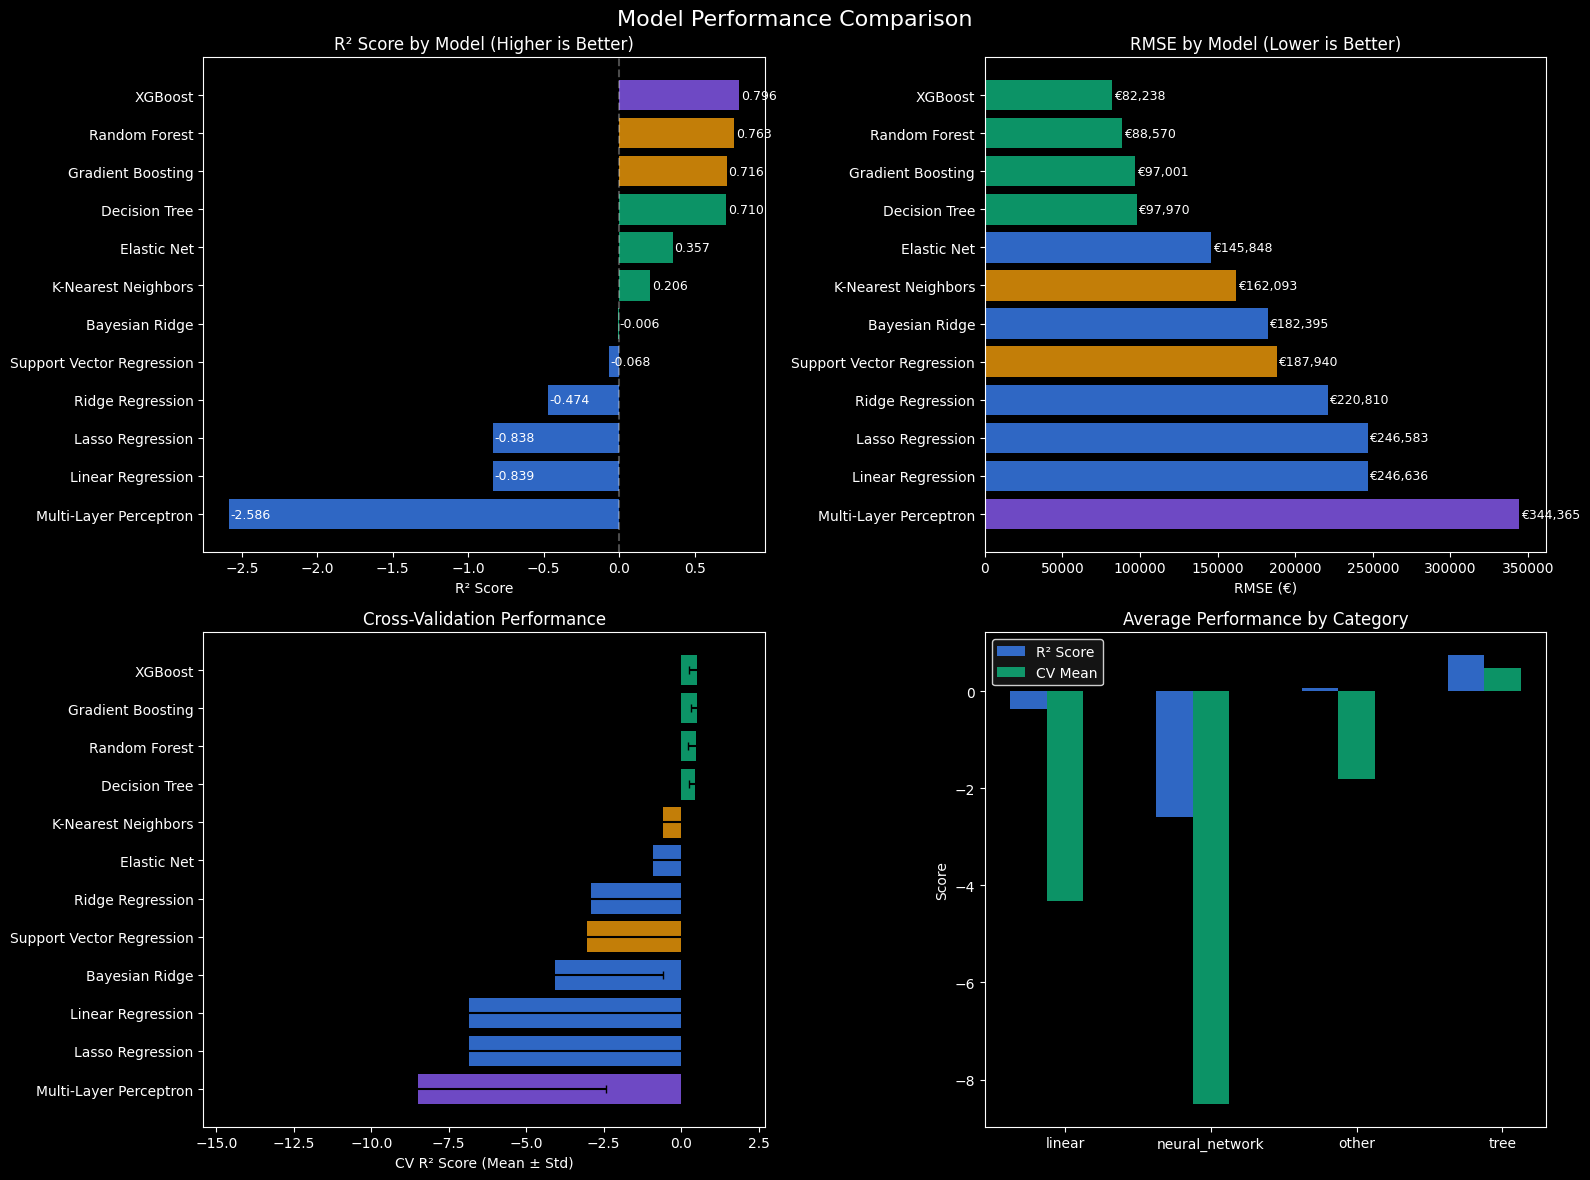


📊 Category Legend:
   LINEAR: #3b82f6
   TREE: #10b981
   OTHER: #f59e0b
   NEURAL_NETWORK: #8b5cf6


In [52]:
# ============================================
# MODEL COMPARISON VISUALIZATIONS
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Model Performance Comparison', fontsize=16, color='white')

# Color by category
category_colors = {
    'linear': '#3b82f6',      # Blue
    'tree': '#10b981',        # Green
    'other': '#f59e0b',       # Orange
    'neural_network': '#8b5cf6',  # Purple
}

# 1. R² Score comparison (sorted)
ax1 = axes[0, 0]
sorted_results = results_df.sort_values('R² Score', ascending=True)
colors = [category_colors[r['category']] for r in results if r['name'] in sorted_results['Model'].values]
bars = ax1.barh(sorted_results['Model'], sorted_results['R² Score'], color=colors, alpha=0.8)
ax1.set_xlabel('R² Score', color='white')
ax1.set_title('R² Score by Model (Higher is Better)', color='white')
ax1.tick_params(colors='white')
ax1.axvline(x=0, color='white', linestyle='--', alpha=0.3)
for i, v in enumerate(sorted_results['R² Score']):
    ax1.text(v + 0.01, i, f'{v:.3f}', va='center', color='white', fontsize=9)

# 2. RMSE comparison (sorted)
ax2 = axes[0, 1]
sorted_rmse = results_df.sort_values('RMSE (€)', ascending=False)
colors = [category_colors[next(r['category'] for r in results if r['name'] == m)] for m in sorted_rmse['Model']]
bars = ax2.barh(sorted_rmse['Model'], sorted_rmse['RMSE (€)'], color=colors, alpha=0.8)
ax2.set_xlabel('RMSE (€)', color='white')
ax2.set_title('RMSE by Model (Lower is Better)', color='white')
ax2.tick_params(colors='white')
for i, v in enumerate(sorted_rmse['RMSE (€)']):
    ax2.text(v + 1000, i, f'€{v:,.0f}', va='center', color='white', fontsize=9)

# 3. Cross-validation comparison with error bars
ax3 = axes[1, 0]
models_sorted = results_df.sort_values('CV Mean', ascending=True)
x_pos = range(len(models_sorted))
colors = [category_colors[next(r['category'] for r in results if r['name'] == m)] for m in models_sorted['Model']]
ax3.barh(models_sorted['Model'], models_sorted['CV Mean'], 
         xerr=models_sorted['CV Std'], color=colors, alpha=0.8, capsize=3)
ax3.set_xlabel('CV R² Score (Mean ± Std)', color='white')
ax3.set_title('Cross-Validation Performance', color='white')
ax3.tick_params(colors='white')

# 4. Category comparison
ax4 = axes[1, 1]
category_means = results_df.groupby('Category').agg({
    'R² Score': 'mean',
    'RMSE (€)': 'mean',
    'CV Mean': 'mean'
}).reset_index()

x = np.arange(len(category_means))
width = 0.25
ax4.bar(x - width, category_means['R² Score'], width, label='R² Score', color='#3b82f6', alpha=0.8)
ax4.bar(x, category_means['CV Mean'], width, label='CV Mean', color='#10b981', alpha=0.8)
ax4.set_xticks(x)
ax4.set_xticklabels(category_means['Category'], color='white')
ax4.set_ylabel('Score', color='white')
ax4.set_title('Average Performance by Category', color='white')
ax4.tick_params(colors='white')
ax4.legend(facecolor='#1a1a1a', edgecolor='white', labelcolor='white')

plt.tight_layout()
plt.show()

# Legend
print("\n📊 Category Legend:")
for cat, color in category_colors.items():
    print(f"   {cat.upper()}: {color}")


## 7. Feature Importance Analysis


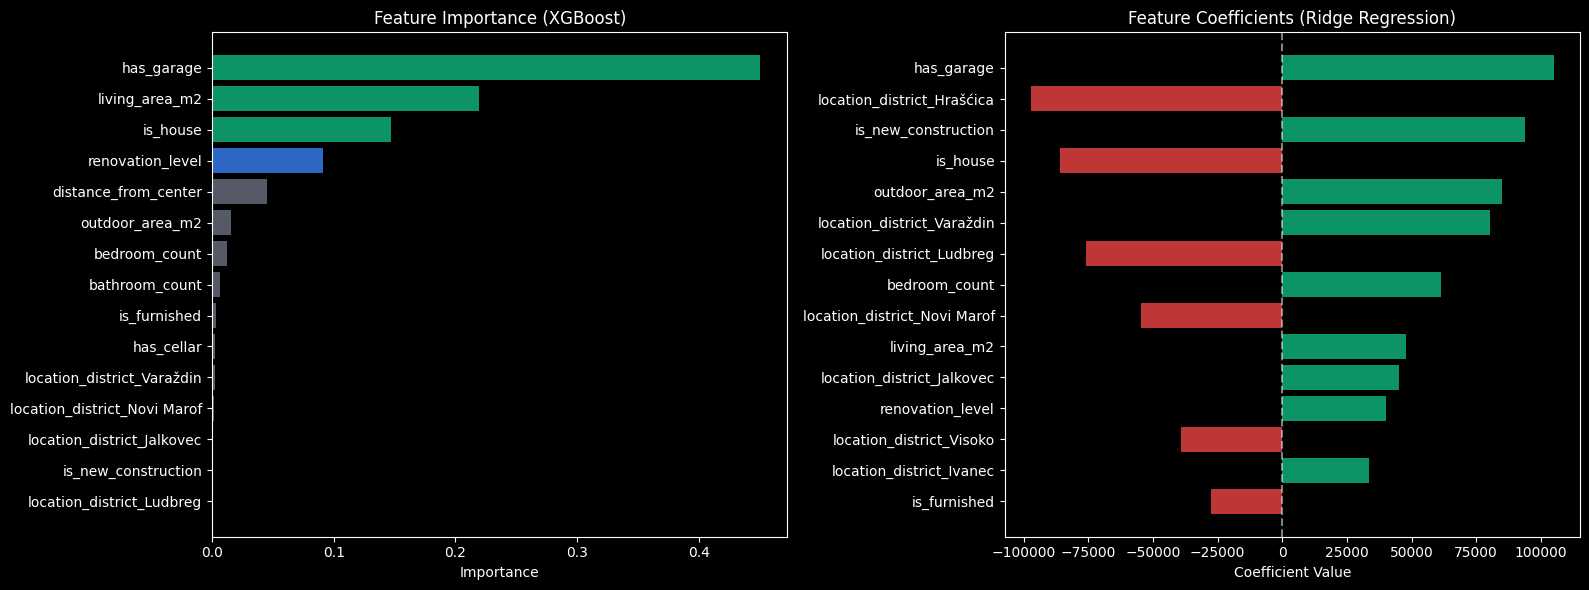


📊 Top 5 Most Important Features:
   1. has_garage: 0.4505
   2. living_area_m2: 0.2197
   3. is_house: 0.1469
   4. renovation_level: 0.0914
   5. distance_from_center: 0.0454


In [53]:
# ============================================
# FEATURE IMPORTANCE ANALYSIS
# ============================================

# Find models with feature importance (tree-based)
tree_results = [r for r in results if r['feature_importance'] is not None]
linear_results = [r for r in results if r['coefficients'] is not None]

if tree_results:
    # Use best performing tree model
    best_tree = max(tree_results, key=lambda x: x['r2_score'])
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Feature importance from tree model
    ax1 = axes[0]
    fi = best_tree['feature_importance']
    fi_sorted = dict(sorted(fi.items(), key=lambda x: x[1], reverse=True))
    features = list(fi_sorted.keys())
    importance = list(fi_sorted.values())
    
    colors = ['#10b981' if v > 0.1 else '#3b82f6' if v > 0.05 else '#6b7280' for v in importance]
    ax1.barh(features[:15], importance[:15], color=colors, alpha=0.8)
    ax1.set_xlabel('Importance', color='white')
    ax1.set_title(f'Feature Importance ({best_tree["name"]})', color='white')
    ax1.tick_params(colors='white')
    ax1.invert_yaxis()
    
    # Coefficients from linear model (Ridge recommended)
    ax2 = axes[1]
    if linear_results:
        ridge_result = next((r for r in linear_results if r['model_key'] == 'ridge'), linear_results[0])
        coef = ridge_result['coefficients']
        coef_sorted = dict(sorted(coef.items(), key=lambda x: abs(x[1]), reverse=True))
        features = list(coef_sorted.keys())
        coefficients = list(coef_sorted.values())
        
        colors = ['#10b981' if v > 0 else '#ef4444' for v in coefficients]
        ax2.barh(features[:15], coefficients[:15], color=colors, alpha=0.8)
        ax2.set_xlabel('Coefficient Value', color='white')
        ax2.set_title(f'Feature Coefficients ({ridge_result["name"]})', color='white')
        ax2.tick_params(colors='white')
        ax2.axvline(x=0, color='white', linestyle='--', alpha=0.5)
        ax2.invert_yaxis()
    
    plt.tight_layout()
    plt.show()
    
    print("\n📊 Top 5 Most Important Features:")
    for i, (feat, imp) in enumerate(list(fi_sorted.items())[:5], 1):
        print(f"   {i}. {feat}: {imp:.4f}")
else:
    print("⚠️ No tree-based models trained successfully")


## 8. Predictions vs Actual (Best Model)


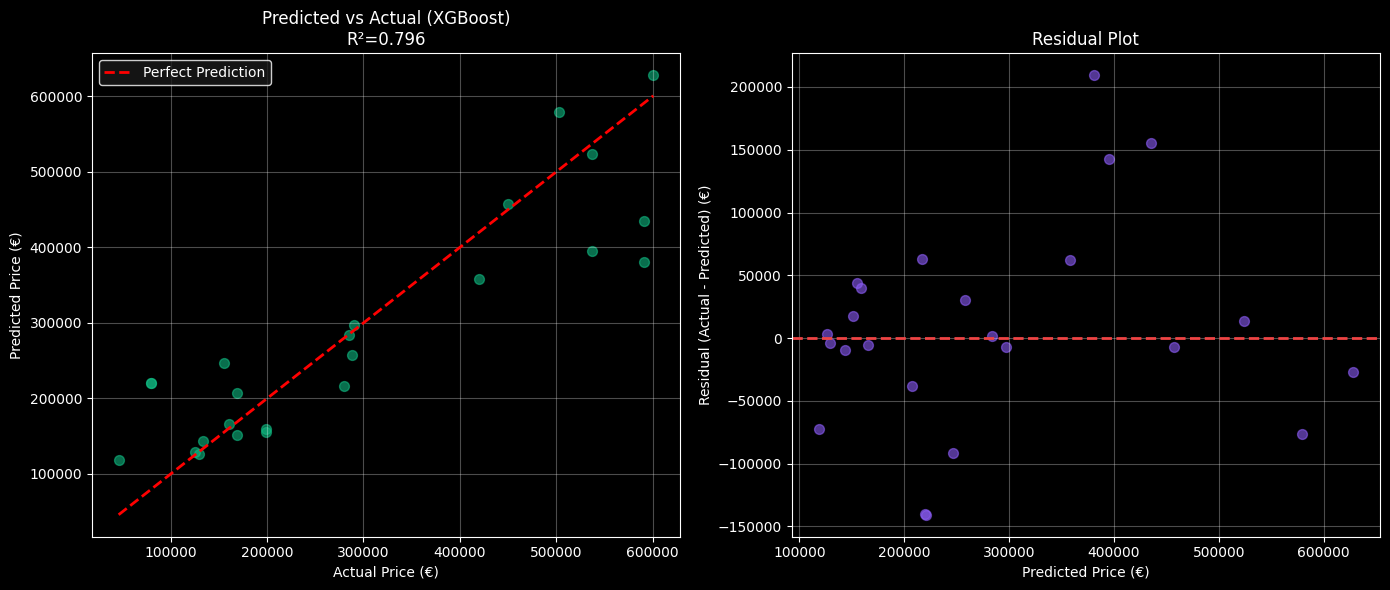


🏆 Best Model: XGBoost
   R² Score: 0.7955
   RMSE: €82,238
   MAE: €58,438
   CV Mean: 0.5096 (±0.2649)


In [54]:
# ============================================
# PREDICTIONS VS ACTUAL - Best performing model
# ============================================

# Find best model by R² score
best_result = max(results, key=lambda x: x['r2_score'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter plot: Predicted vs Actual
ax1 = axes[0]
y_pred_best = best_result['predictions']
ax1.scatter(y_test, y_pred_best, c='#10b981', alpha=0.6, s=50)
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', linewidth=2, label='Perfect Prediction')
ax1.set_xlabel('Actual Price (€)', color='white')
ax1.set_ylabel('Predicted Price (€)', color='white')
ax1.set_title(f'Predicted vs Actual ({best_result["name"]})\nR²={best_result["r2_score"]:.3f}', color='white')
ax1.tick_params(colors='white')
ax1.legend(facecolor='#1a1a1a', edgecolor='white', labelcolor='white')
ax1.grid(True, alpha=0.3)

# Residuals plot
ax2 = axes[1]
residuals = y_test - y_pred_best
ax2.scatter(y_pred_best, residuals, c='#8b5cf6', alpha=0.6, s=50)
ax2.axhline(y=0, color='#ef4444', linestyle='--', linewidth=2)
ax2.set_xlabel('Predicted Price (€)', color='white')
ax2.set_ylabel('Residual (Actual - Predicted) (€)', color='white')
ax2.set_title('Residual Plot', color='white')
ax2.tick_params(colors='white')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n🏆 Best Model: {best_result['name']}")
print(f"   R² Score: {best_result['r2_score']:.4f}")
print(f"   RMSE: €{best_result['rmse']:,.0f}")
print(f"   MAE: €{best_result['mae']:,.0f}")
print(f"   CV Mean: {best_result['cv_mean']:.4f} (±{best_result['cv_std']:.4f})")


## 9. Correlation Matrix


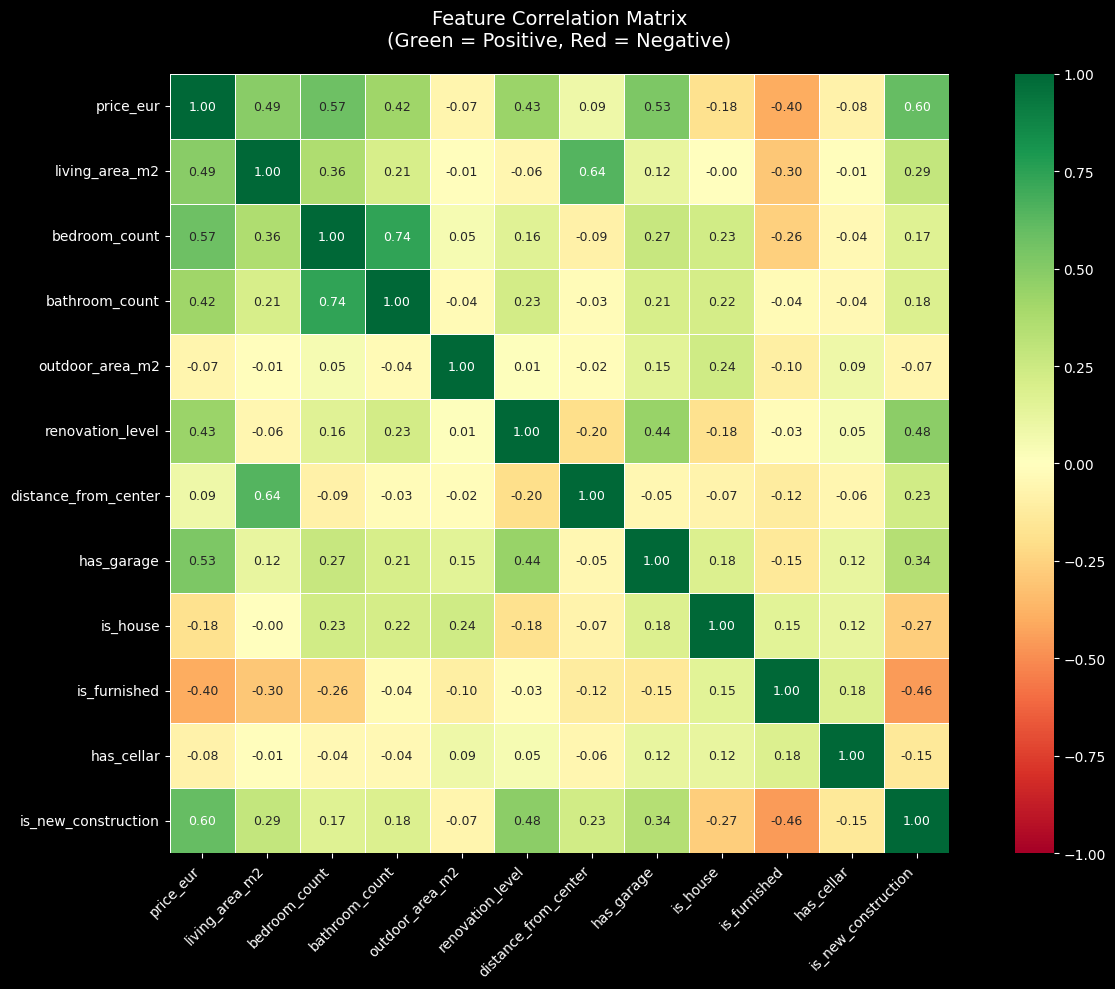


📊 CORRELATIONS WITH PRICE:
🟢 is_new_construction: 0.598
🟢 bedroom_count: 0.571
🟢 has_garage: 0.526
🟢 living_area_m2: 0.487
🟢 renovation_level: 0.434
🟢 bathroom_count: 0.421
🔴 is_furnished: -0.399
⚪ is_house: -0.185
⚪ distance_from_center: 0.088
⚪ has_cellar: -0.079
⚪ outdoor_area_m2: -0.066


In [55]:
# ============================================
# CORRELATION MATRIX - Matching MLService.calculate_correlation_matrix
# ============================================

# Get correlation columns (numeric, derived, boolean - not categorical)
corr_cols = [TARGET] + NUMERIC_FEATURES + DERIVED_FEATURES + BOOLEAN_FEATURES
available_corr_cols = [c for c in corr_cols if c in df_ml.columns]

# Calculate correlation matrix
df_corr = df_ml[available_corr_cols].copy()
corr_matrix = df_corr.corr()

# Create heatmap
fig, ax = plt.subplots(figsize=(14, 10))

sns.heatmap(corr_matrix, 
            annot=True, 
            cmap='RdYlGn', 
            center=0,
            vmin=-1, vmax=1,
            square=True, 
            linewidths=0.5, 
            fmt='.2f',
            annot_kws={'size': 9},
            ax=ax)

ax.set_title('Feature Correlation Matrix\n(Green = Positive, Red = Negative)', 
             color='white', fontsize=14, pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Print correlations with target (price)
print("\n📊 CORRELATIONS WITH PRICE:")
print("=" * 50)
price_corr = corr_matrix[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
for feature, corr in price_corr.items():
    emoji = "🟢" if corr > 0.3 else "🔴" if corr < -0.3 else "⚪"
    print(f"{emoji} {feature}: {corr:.3f}")


## 10. Summary & Recommendations


In [56]:
# Correlation matrix for numeric features
corr_cols = ['price_eur', 'living_area_m2', 'outdoor_area_m2', 'bedroom_count', 
             'bathroom_count', 'renovation_level', 'distance_from_center', 'price_per_m2']

# Filter to only columns that exist
available_cols = [col for col in corr_cols if col in df_valid.columns]
corr_data = df_valid[available_cols].dropna()

print(f"Computing correlation matrix for {len(available_cols)} features...")
print(f"Using {len(corr_data)} complete records\n")

corr_matrix = corr_data.corr()

# Create heatmap
fig, ax = plt.subplots(figsize=(12, 10))

sns.heatmap(corr_matrix, 
            annot=True, 
            cmap='RdYlGn', 
            center=0,
            vmin=-1, vmax=1,
            square=True, 
            linewidths=0.5, 
            fmt='.2f',
            annot_kws={'size': 10},
            ax=ax)

ax.set_title('Feature Correlation Matrix\n(Green = Positive, Red = Negative)', 
             color='white', fontsize=14, pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Print key correlations with price
print("\n📊 CORRELATIONS WITH PRICE:")
print("=" * 50)
price_corr = corr_matrix['price_eur'].drop('price_eur').sort_values(ascending=False)
for feature, corr in price_corr.items():
    emoji = "🟢" if corr > 0.3 else "🔴" if corr < -0.3 else "⚪"
    print(f"{emoji} {feature}: {corr:.3f}")

📊 ML MODEL ANALYSIS SUMMARY

📦 Dataset:
   • Total raw listings: 479
   • After cleaning: 116 (removed 363 outliers)
   • Features used: 22

🏆 Model Rankings (by R² Score):
   1. XGBoost: R²=0.7955, RMSE=€82,238
   2. Random Forest: R²=0.7628, RMSE=€88,570
   3. Gradient Boosting: R²=0.7155, RMSE=€97,001
   4. Decision Tree: R²=0.7098, RMSE=€97,970
   5. Elastic Net: R²=0.3568, RMSE=€145,848

📈 Category Performance:
   TREE            | Avg R²: 0.746 | Best: XGBoost
   LINEAR          | Avg R²: -0.360 | Best: Elastic Net
   OTHER           | Avg R²: 0.069 | Best: K-Nearest Neighbors
   NEURAL_NETWORK  | Avg R²: -2.586 | Best: Multi-Layer Perceptron

💡 RECOMMENDATIONS:
   1. Best overall model: XGBoost (R²=0.796)
   2. For production API: Use Ridge or Gradient Boosting (good balance)
   3. Key features to collect: has_garage, living_area_m2, is_house
   4. Expected prediction accuracy: ±€82,238 (RMSE)

✅ Analysis complete! Models match production app implementation.


## 11. Export Results

In [45]:
# ============================================
# EXPORT RESULTS
# ============================================

# Save results to CSV
results_df.to_csv('model_comparison_results.csv', index=False)
print("✅ Saved: model_comparison_results.csv")

# Save cleaned data for future use
df_ml.to_csv('cleaned_listings_ml.csv', index=False)
print(f"✅ Saved: cleaned_listings_ml.csv ({len(df_ml)} records)")

# Display final comparison table
print("\n📊 Final Model Comparison:")
results_df.style.background_gradient(subset=['R² Score', 'CV Mean'], cmap='Greens')

✅ Saved: model_comparison_results.csv
✅ Saved: cleaned_listings_ml.csv (89 records)

📊 Final Model Comparison:


AttributeError: The '.style' accessor requires jinja2

## 10. Export Clean Dataset (Optional)


In [ ]:
# End of notebook


📋 listings_v2 Export Columns:
   Schema columns: 37
   Export columns: 32

   Exporting: external_id, url, title, price_eur, location_city, location_district, floor_level, latitude...

📊 Dataset Statistics:
   Original:      479
   Valid:         475
   Clean (export):441

✅ Supabase-compatible: listings_v2_supabase.csv
   Records: 441, Columns: 32
✅ ML-ready: listings_v2_ml.csv
   Records: 441, Columns: 36


,url,price_eur,living_area_m2,building_type,renovation_level
0,https://www.njuskalo.hr/nekretnine/novogradnja...,172152.0,63.76,BUILDING,9.0
1,https://www.njuskalo.hr/nekretnine/varazdin-ce...,420000.0,153.03,BUILDING,9.0
3,https://www.njuskalo.hr/nekretnine/novogradnja...,184545.0,68.35,BUILDING,9.0


In [ ]:
# (Optional additional analysis cells can be added below)


🚀 Inserting clean data into listings_v2...
   Source: 441 records from cleaned dataset
   Processed: 441/441

✅ Inserted: 441 records


(441, 0)

In [ ]:
# This cell left intentionally blank - analysis complete above


Linear Regression | RMSE: 134627.31, R2: nan
Ridge Regression  | RMSE: 134586.09, R2: nan
Lasso Regression  | RMSE: 153928.40, R2: nan
Random Forest     | RMSE: 85830.04, R2: nan


In [ ]:
# Notebook end
